In [1]:
# Test script 2

In [1]:
# Plotting region mortality time series

In [4]:
import os
import xarray as xr
import regionmask
import matplotlib.pyplot as plt
import numpy as np

In [5]:
# === Removing ocean ===
def land_filter(da):
    # Load in land fraction dataset
    land_110 = regionmask.defined_regions.natural_earth_v4_1_0.land_110
    da = da.where(land_110.mask_3D(da).squeeze())
    return da


# === Figure sizing ===
def autosize_figure(nrows, ncolumns, scale_factor=1, xscale_factor=1, yscale_factor=1):
    xwidth = (ncolumns+0.67) * 5.0 * scale_factor * xscale_factor
    ylength = (nrows+0.67) * 3.6 * scale_factor * yscale_factor
    return (xwidth, ylength)

In [3]:
# === Path config ===
DIR = "/glade/work/awells/air_quality/CESM/mortality/"

ssp245 = xr.open_dataarray(f"{DIR}Mortality_Regional_sum_CESM2_SSP245_2020-2069.nc")
arise = xr.open_dataarray(f"{DIR}Mortality_Regional_sum_CESM2_ARISE_2035-2069.nc")

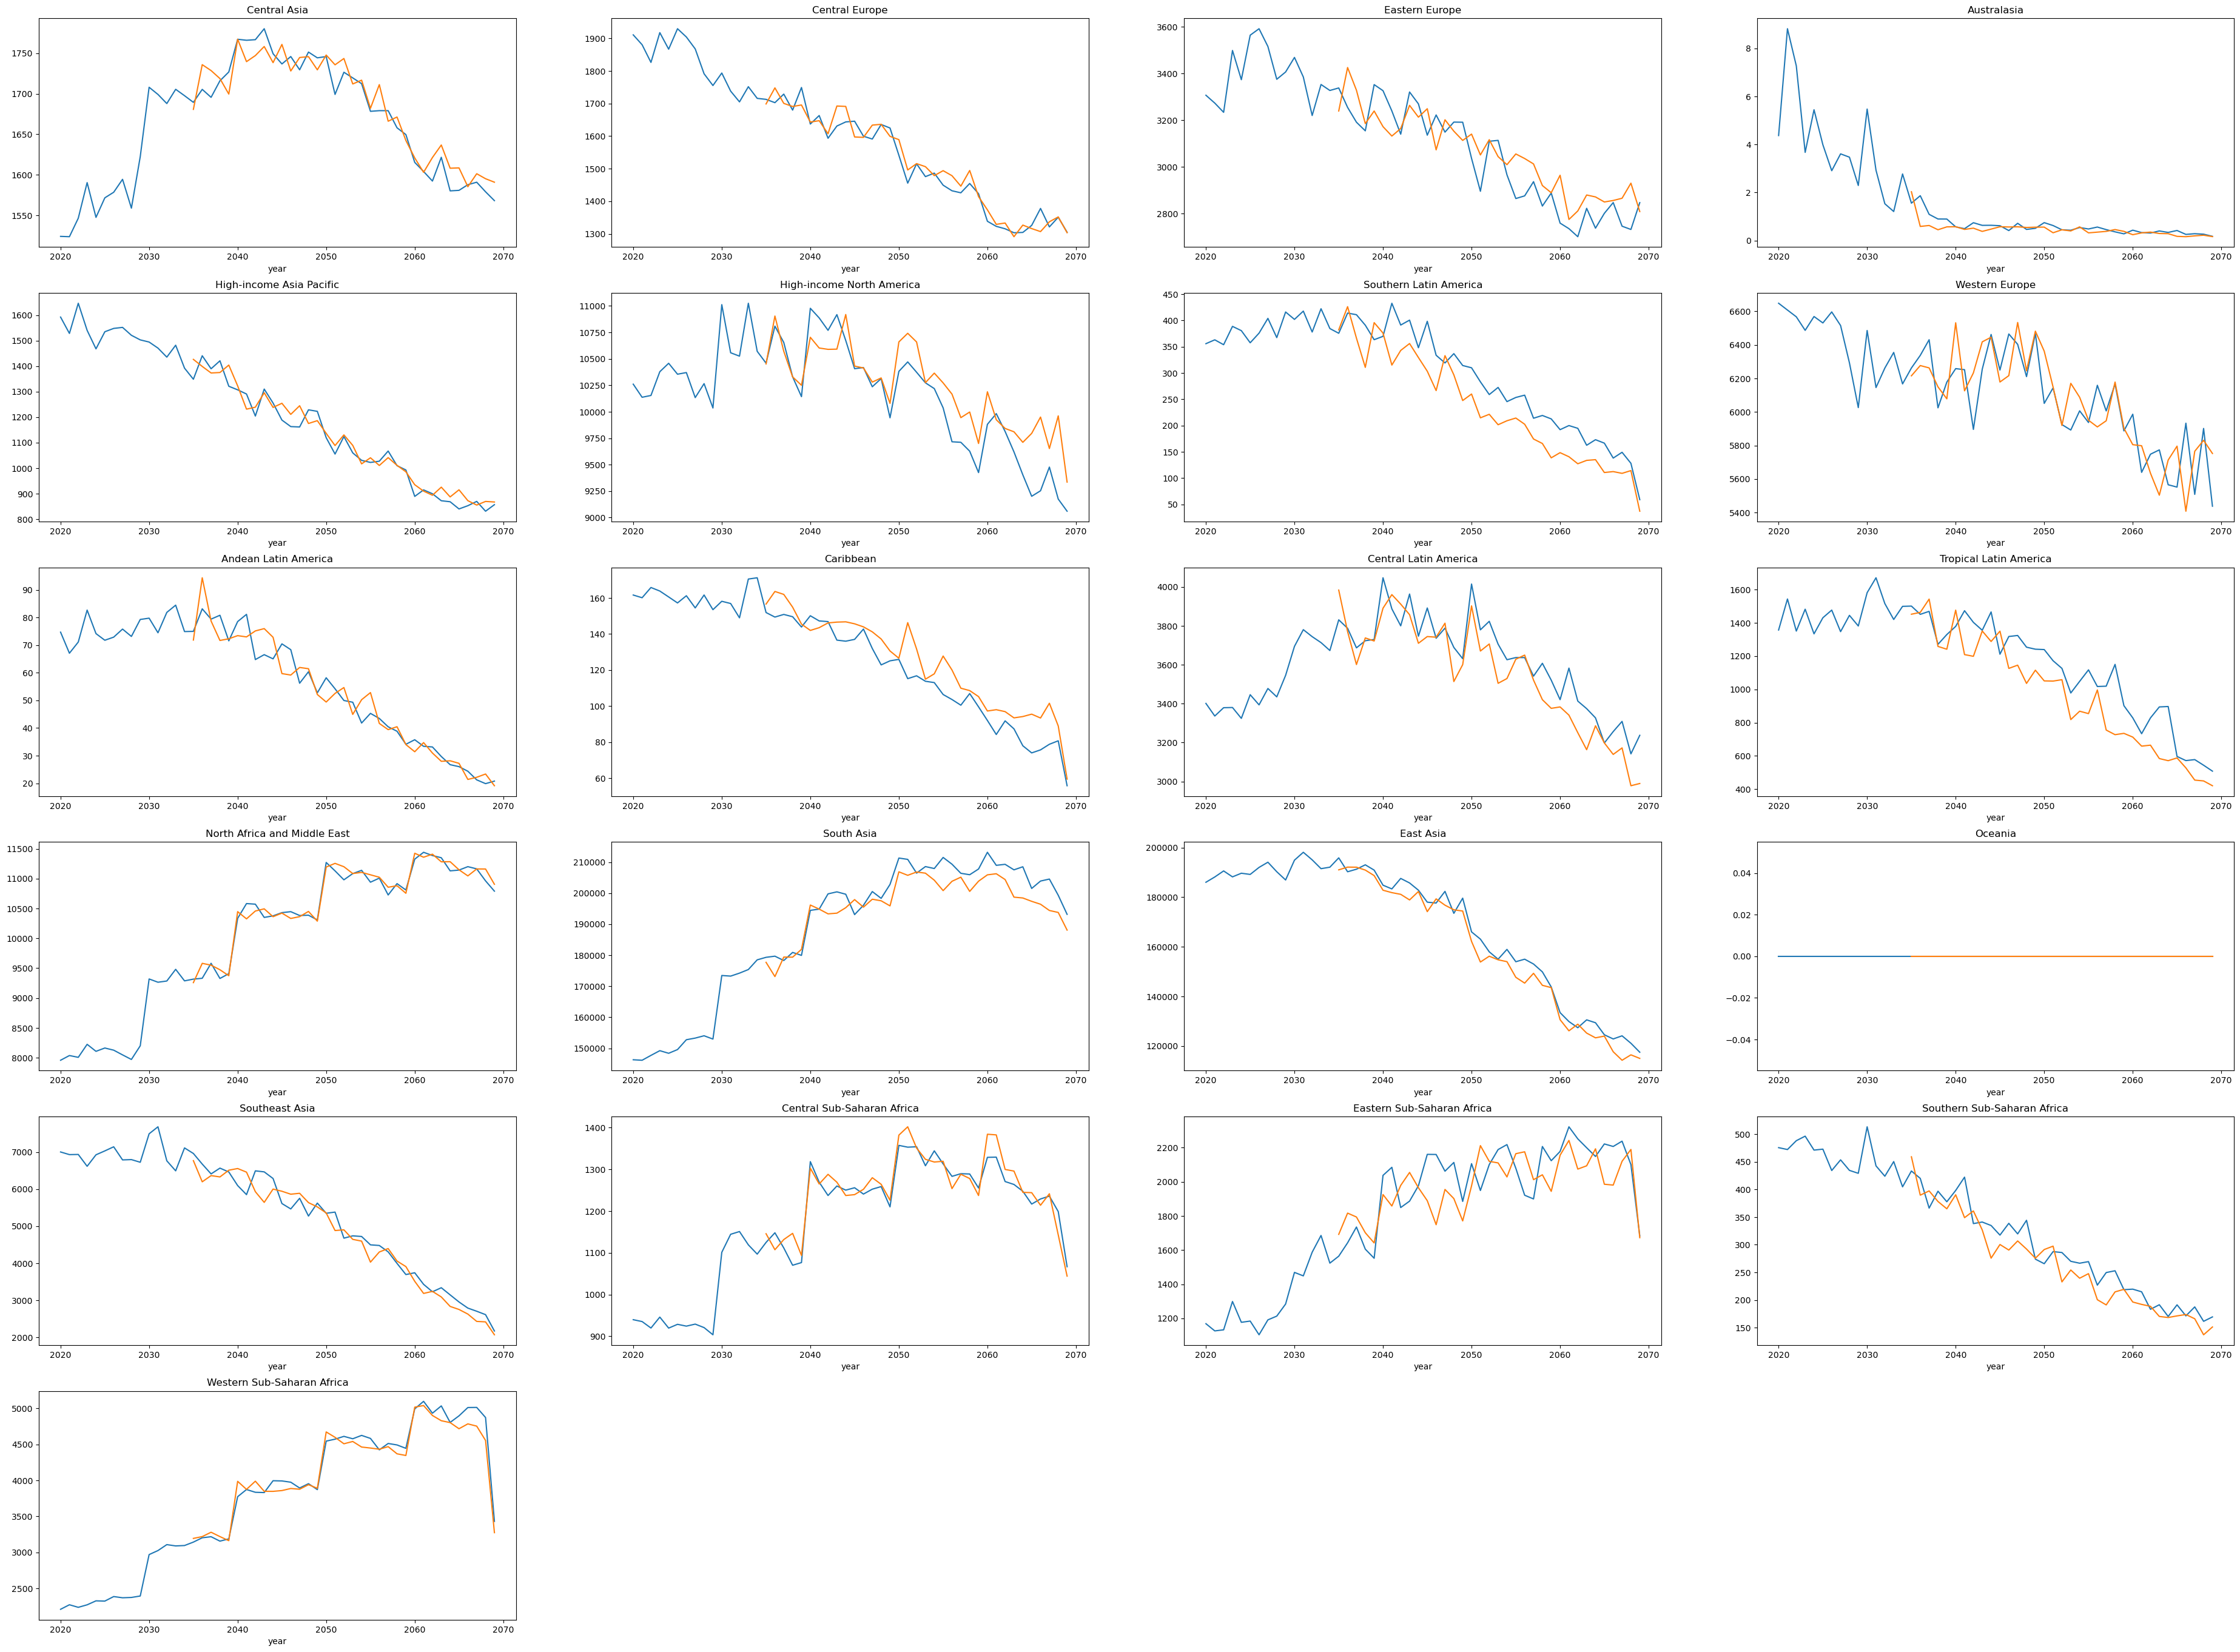

In [4]:
plt.figure(figsize=autosize_figure(5, 4, scale_factor=2, yscale_factor=3))
for i in range(21):
    plt.subplot(21, 4, i+1)
    for ens_num in range(1, 11):
        ssp245.sel(ensemble=ens_num).isel(region=i).plot()
    ssp245.mean("ensemble").isel(region=i).plot()
    arise.mean("ensemble").isel(region=i).plot()
    plt.title(ssp245["region"][i].values)

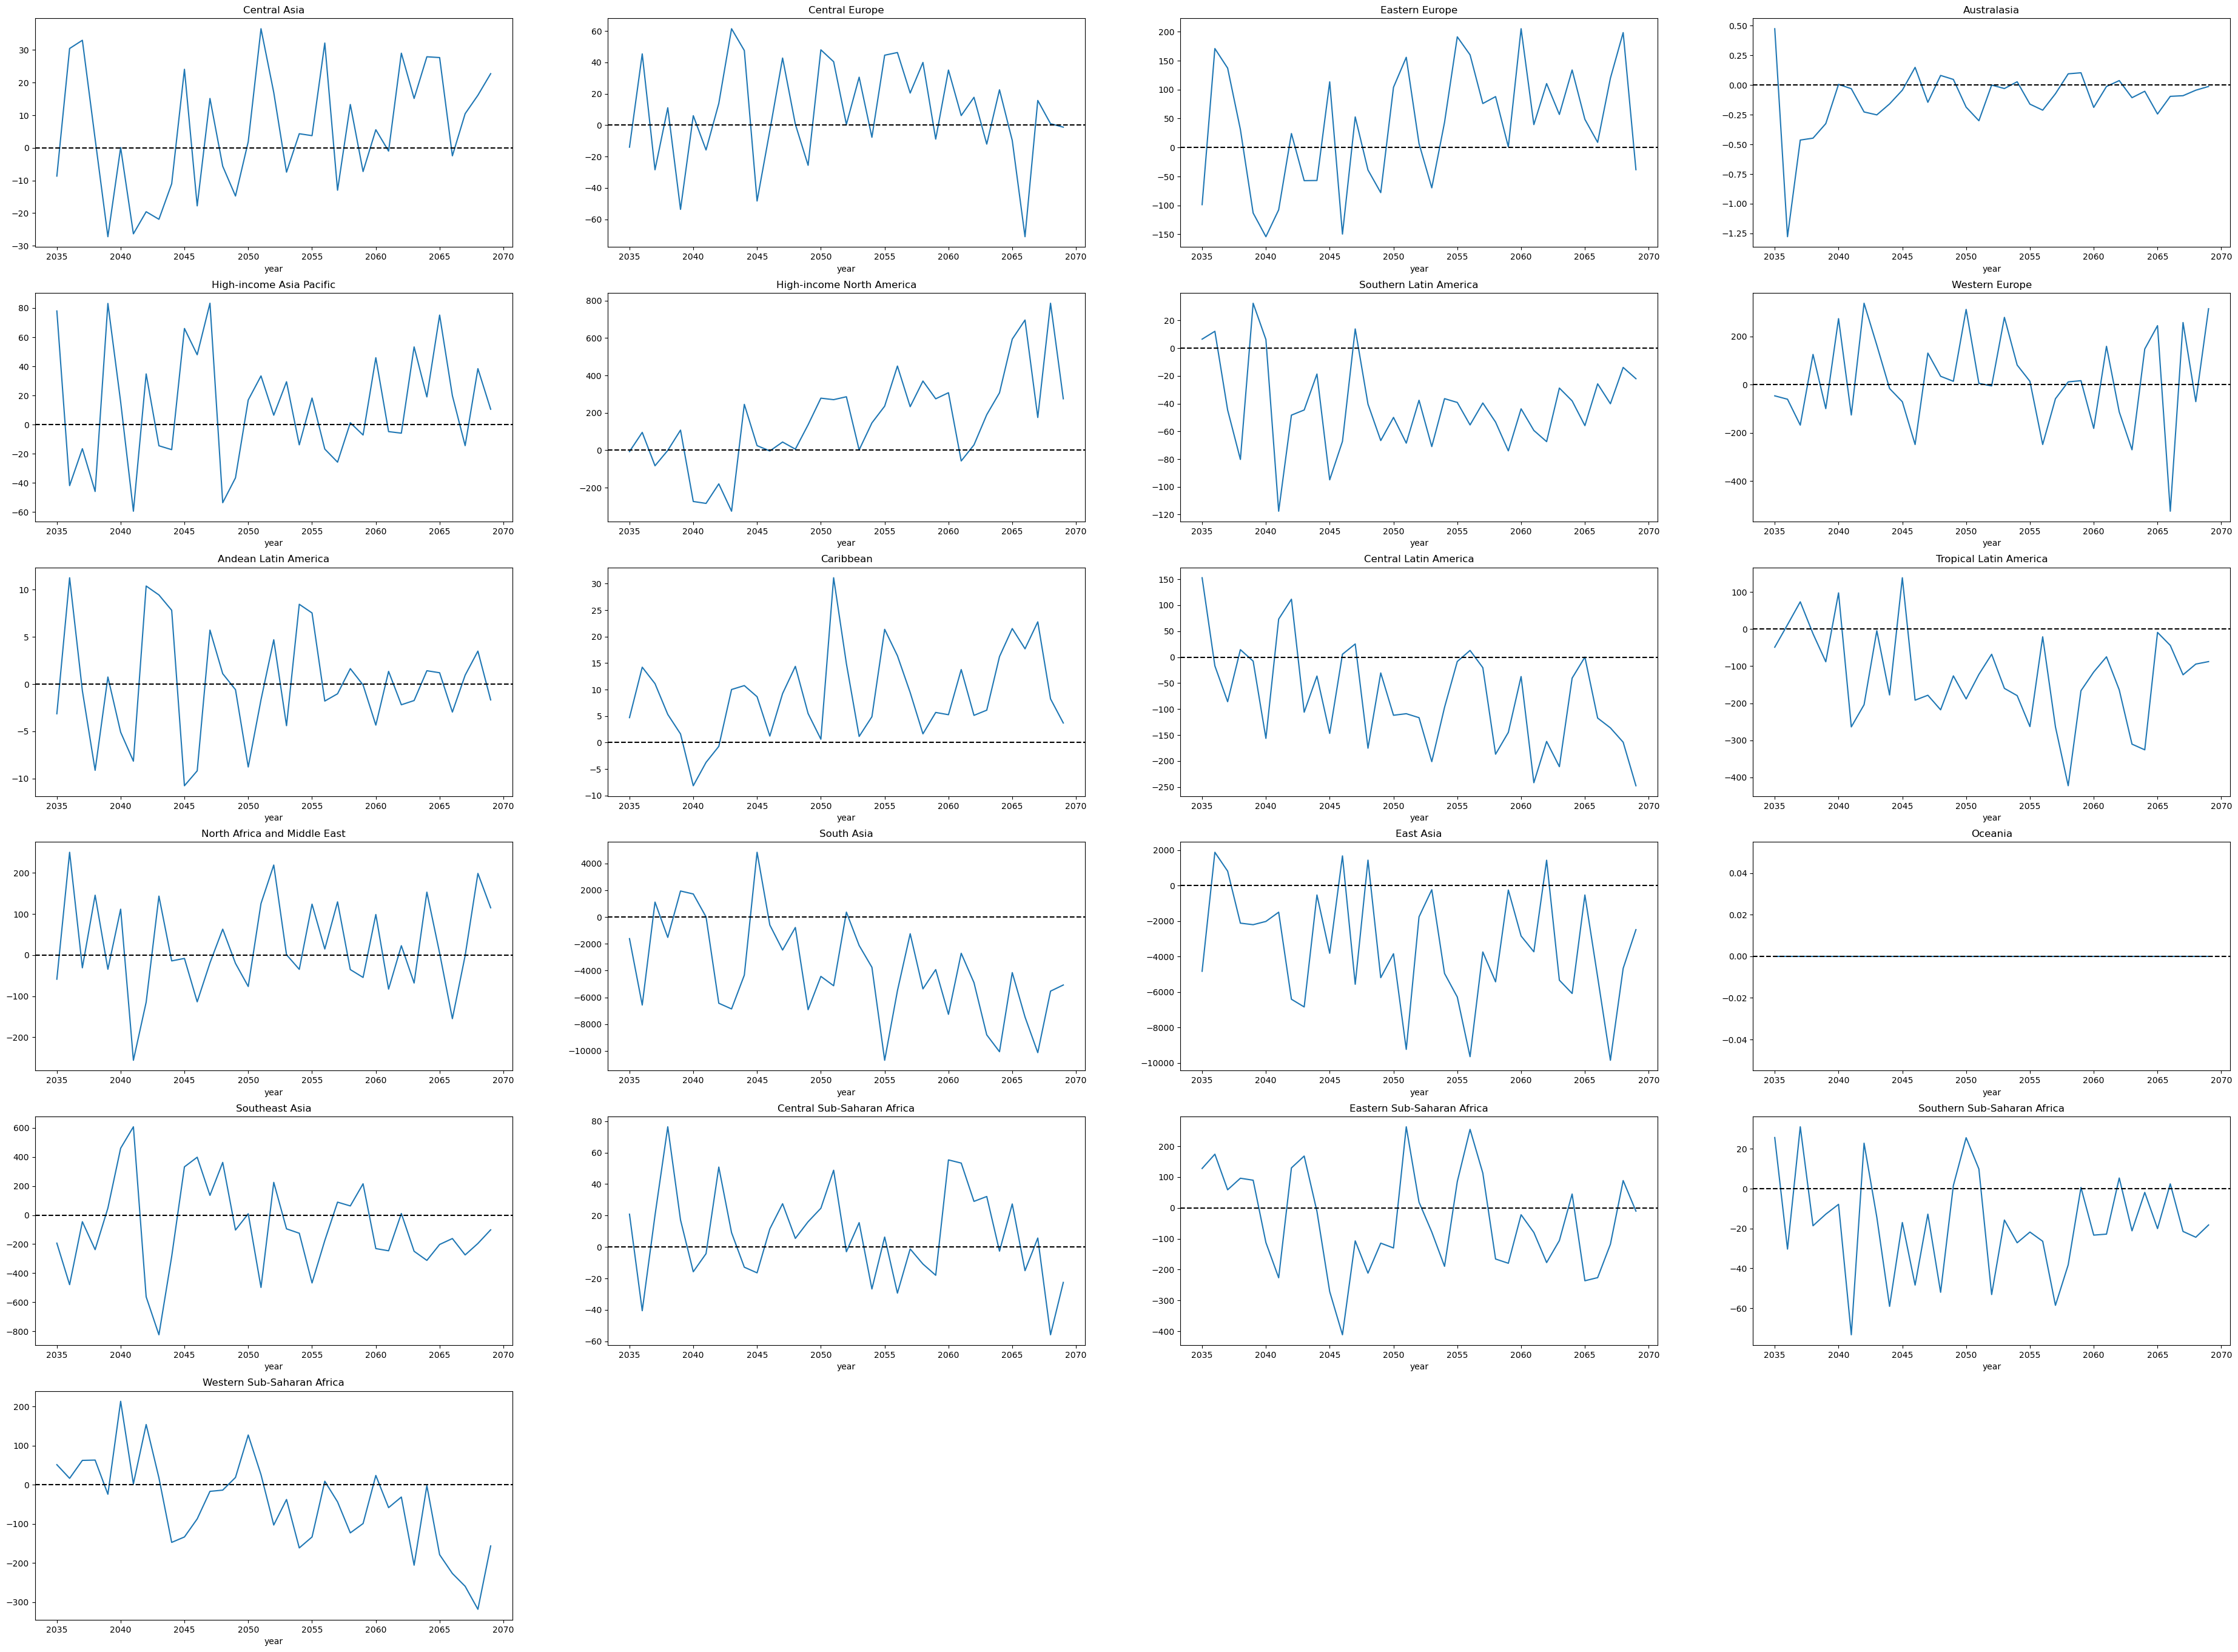

In [5]:
plt.figure(figsize=autosize_figure(5, 4, scale_factor=2, yscale_factor=3))
for i in range(21):
    plt.subplot(21, 4, i+1)
    (arise - ssp245).mean("ensemble").isel(region=i).plot()
    plt.axhline(0, color='k', linestyle='--')
    plt.title(ssp245["region"][i].values)

In [6]:
# === Path config ===
DIR = "/glade/work/awells/air_quality/CESM/ozone/OSDMA8_BC/"

ssp245 = xr.open_dataarray(f"{DIR}OSDMA8_BC_Regional_mean_CESM2_SSP245_2020-2069.nc")
arise = xr.open_dataarray(f"{DIR}OSDMA8_BC_Regional_mean_CESM2_ARISE_2035-2069.nc")

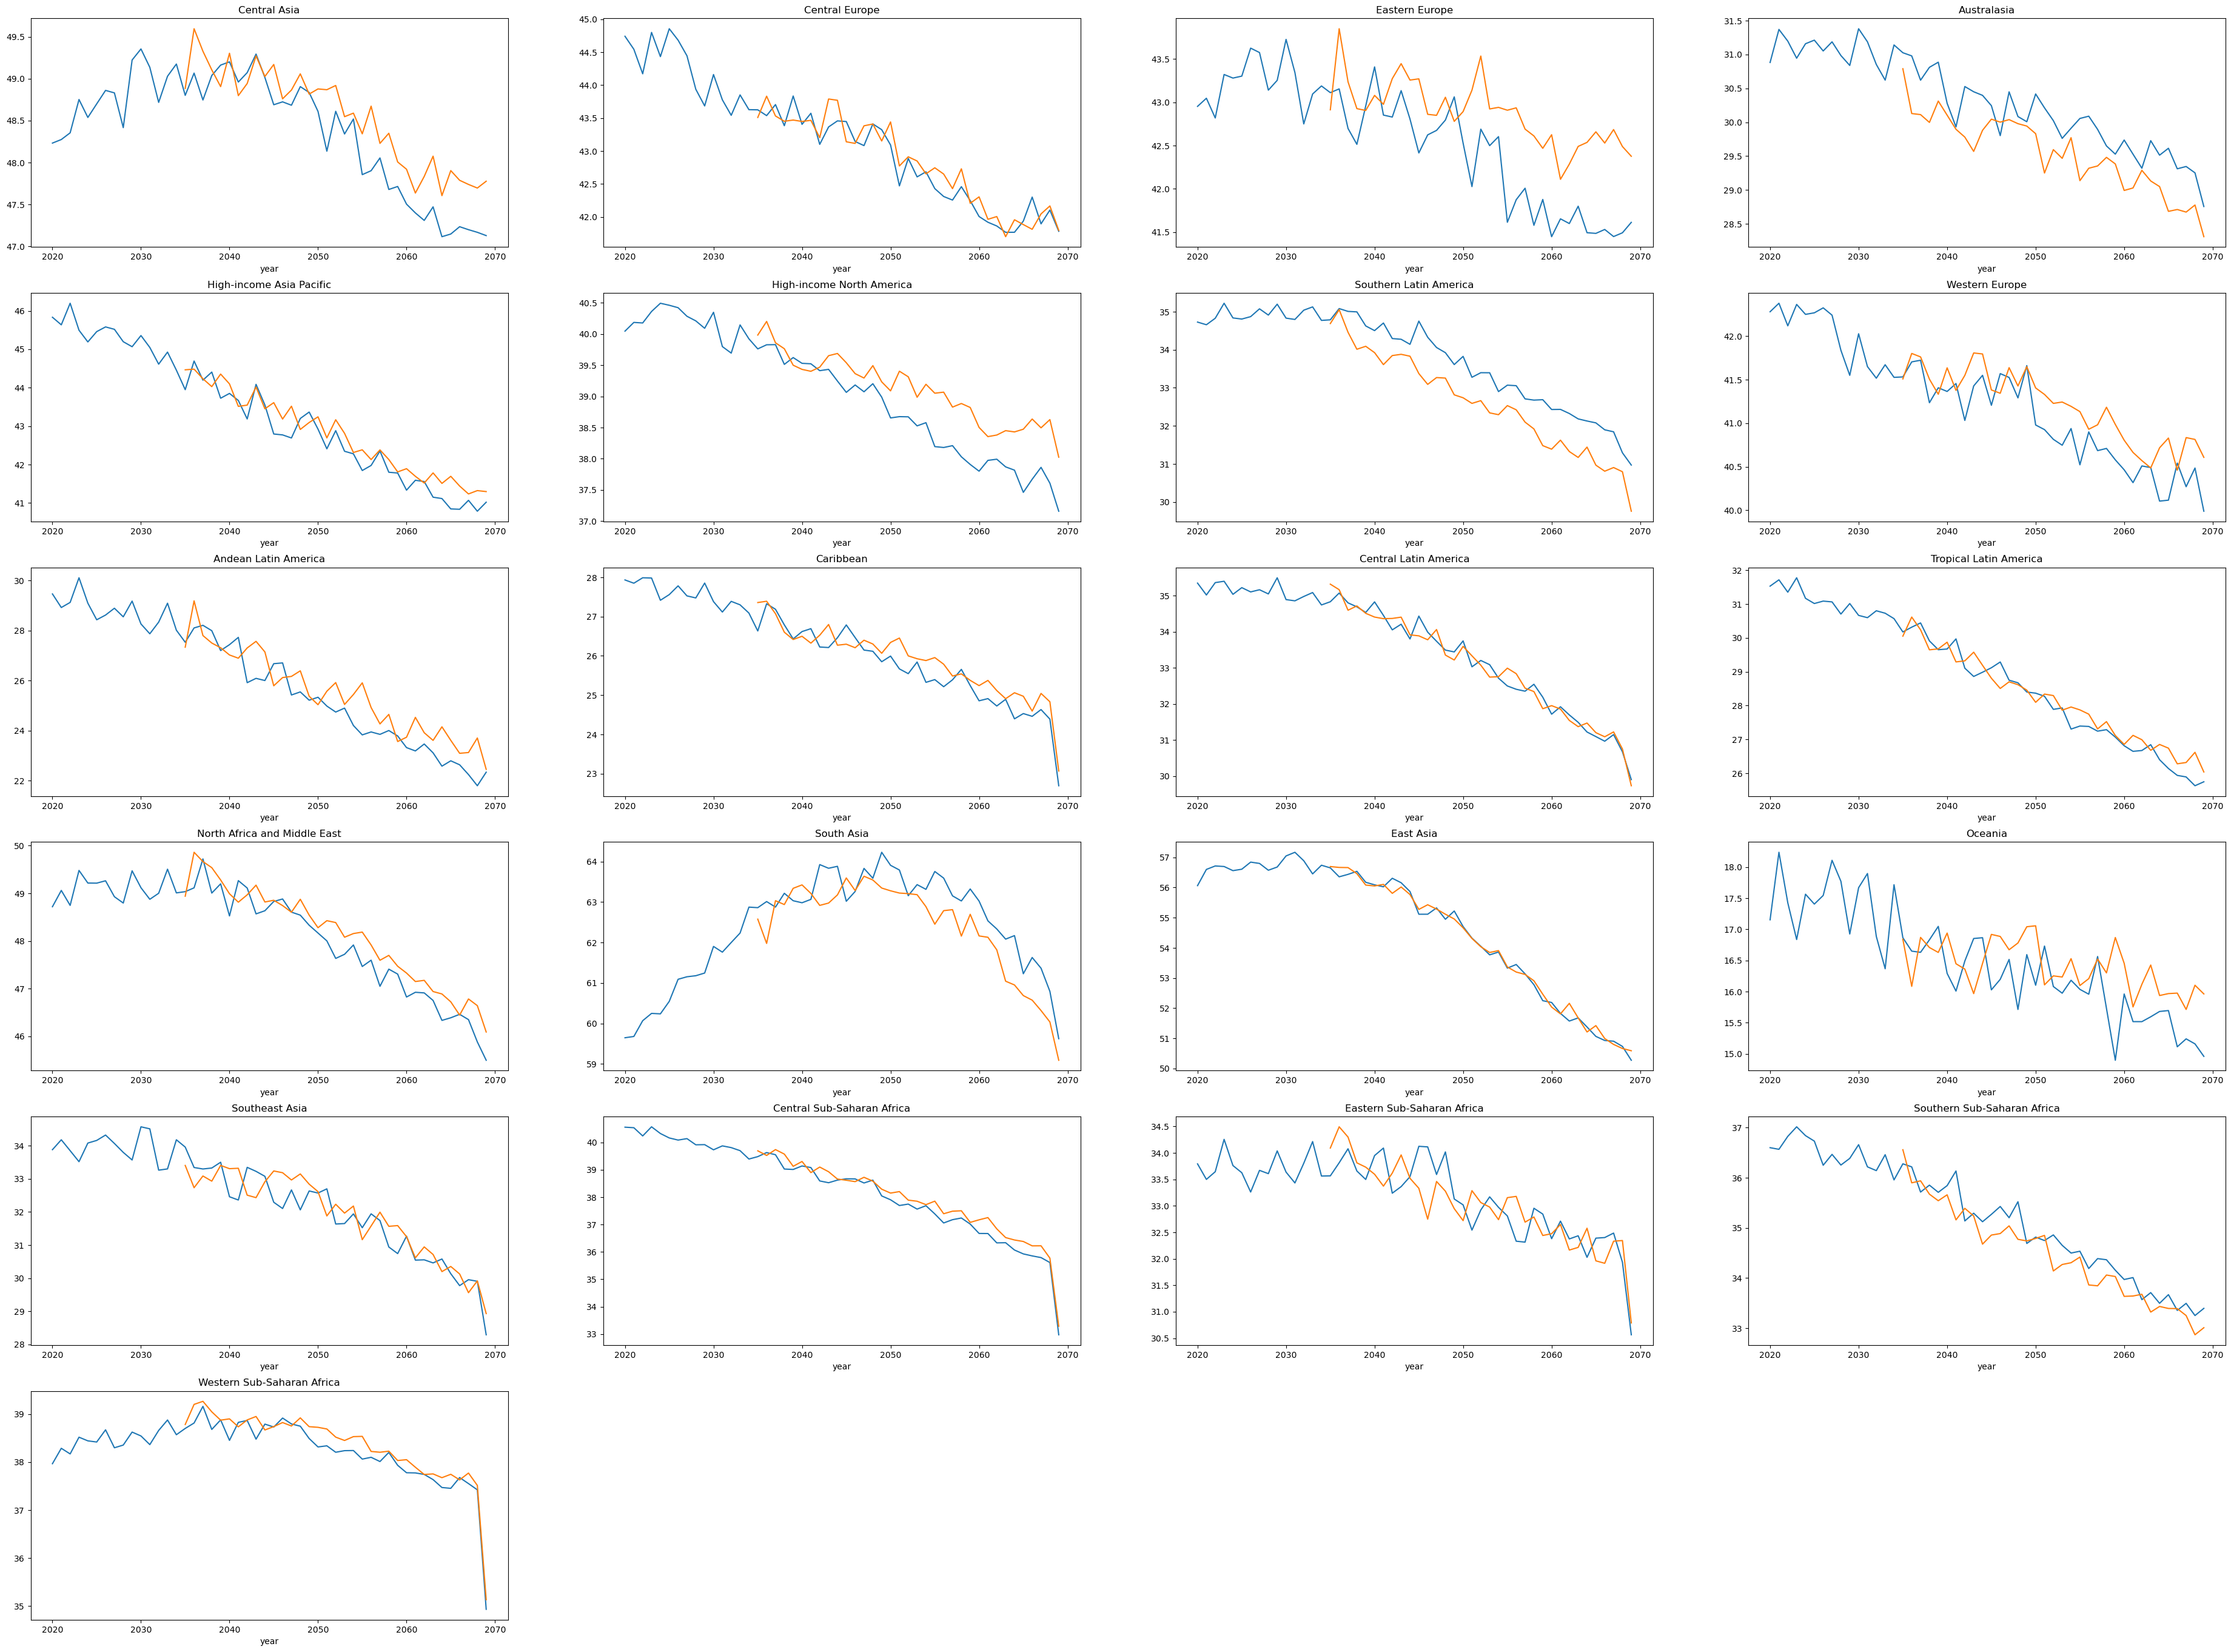

In [7]:
plt.figure(figsize=autosize_figure(5, 4, scale_factor=2, yscale_factor=3))
for i in range(21):
    plt.subplot(21, 4, i+1)
    ssp245.mean("ensemble").isel(region=i).plot()
    arise.mean("ensemble").isel(region=i).plot()
    plt.title(ssp245["region"][i].values)

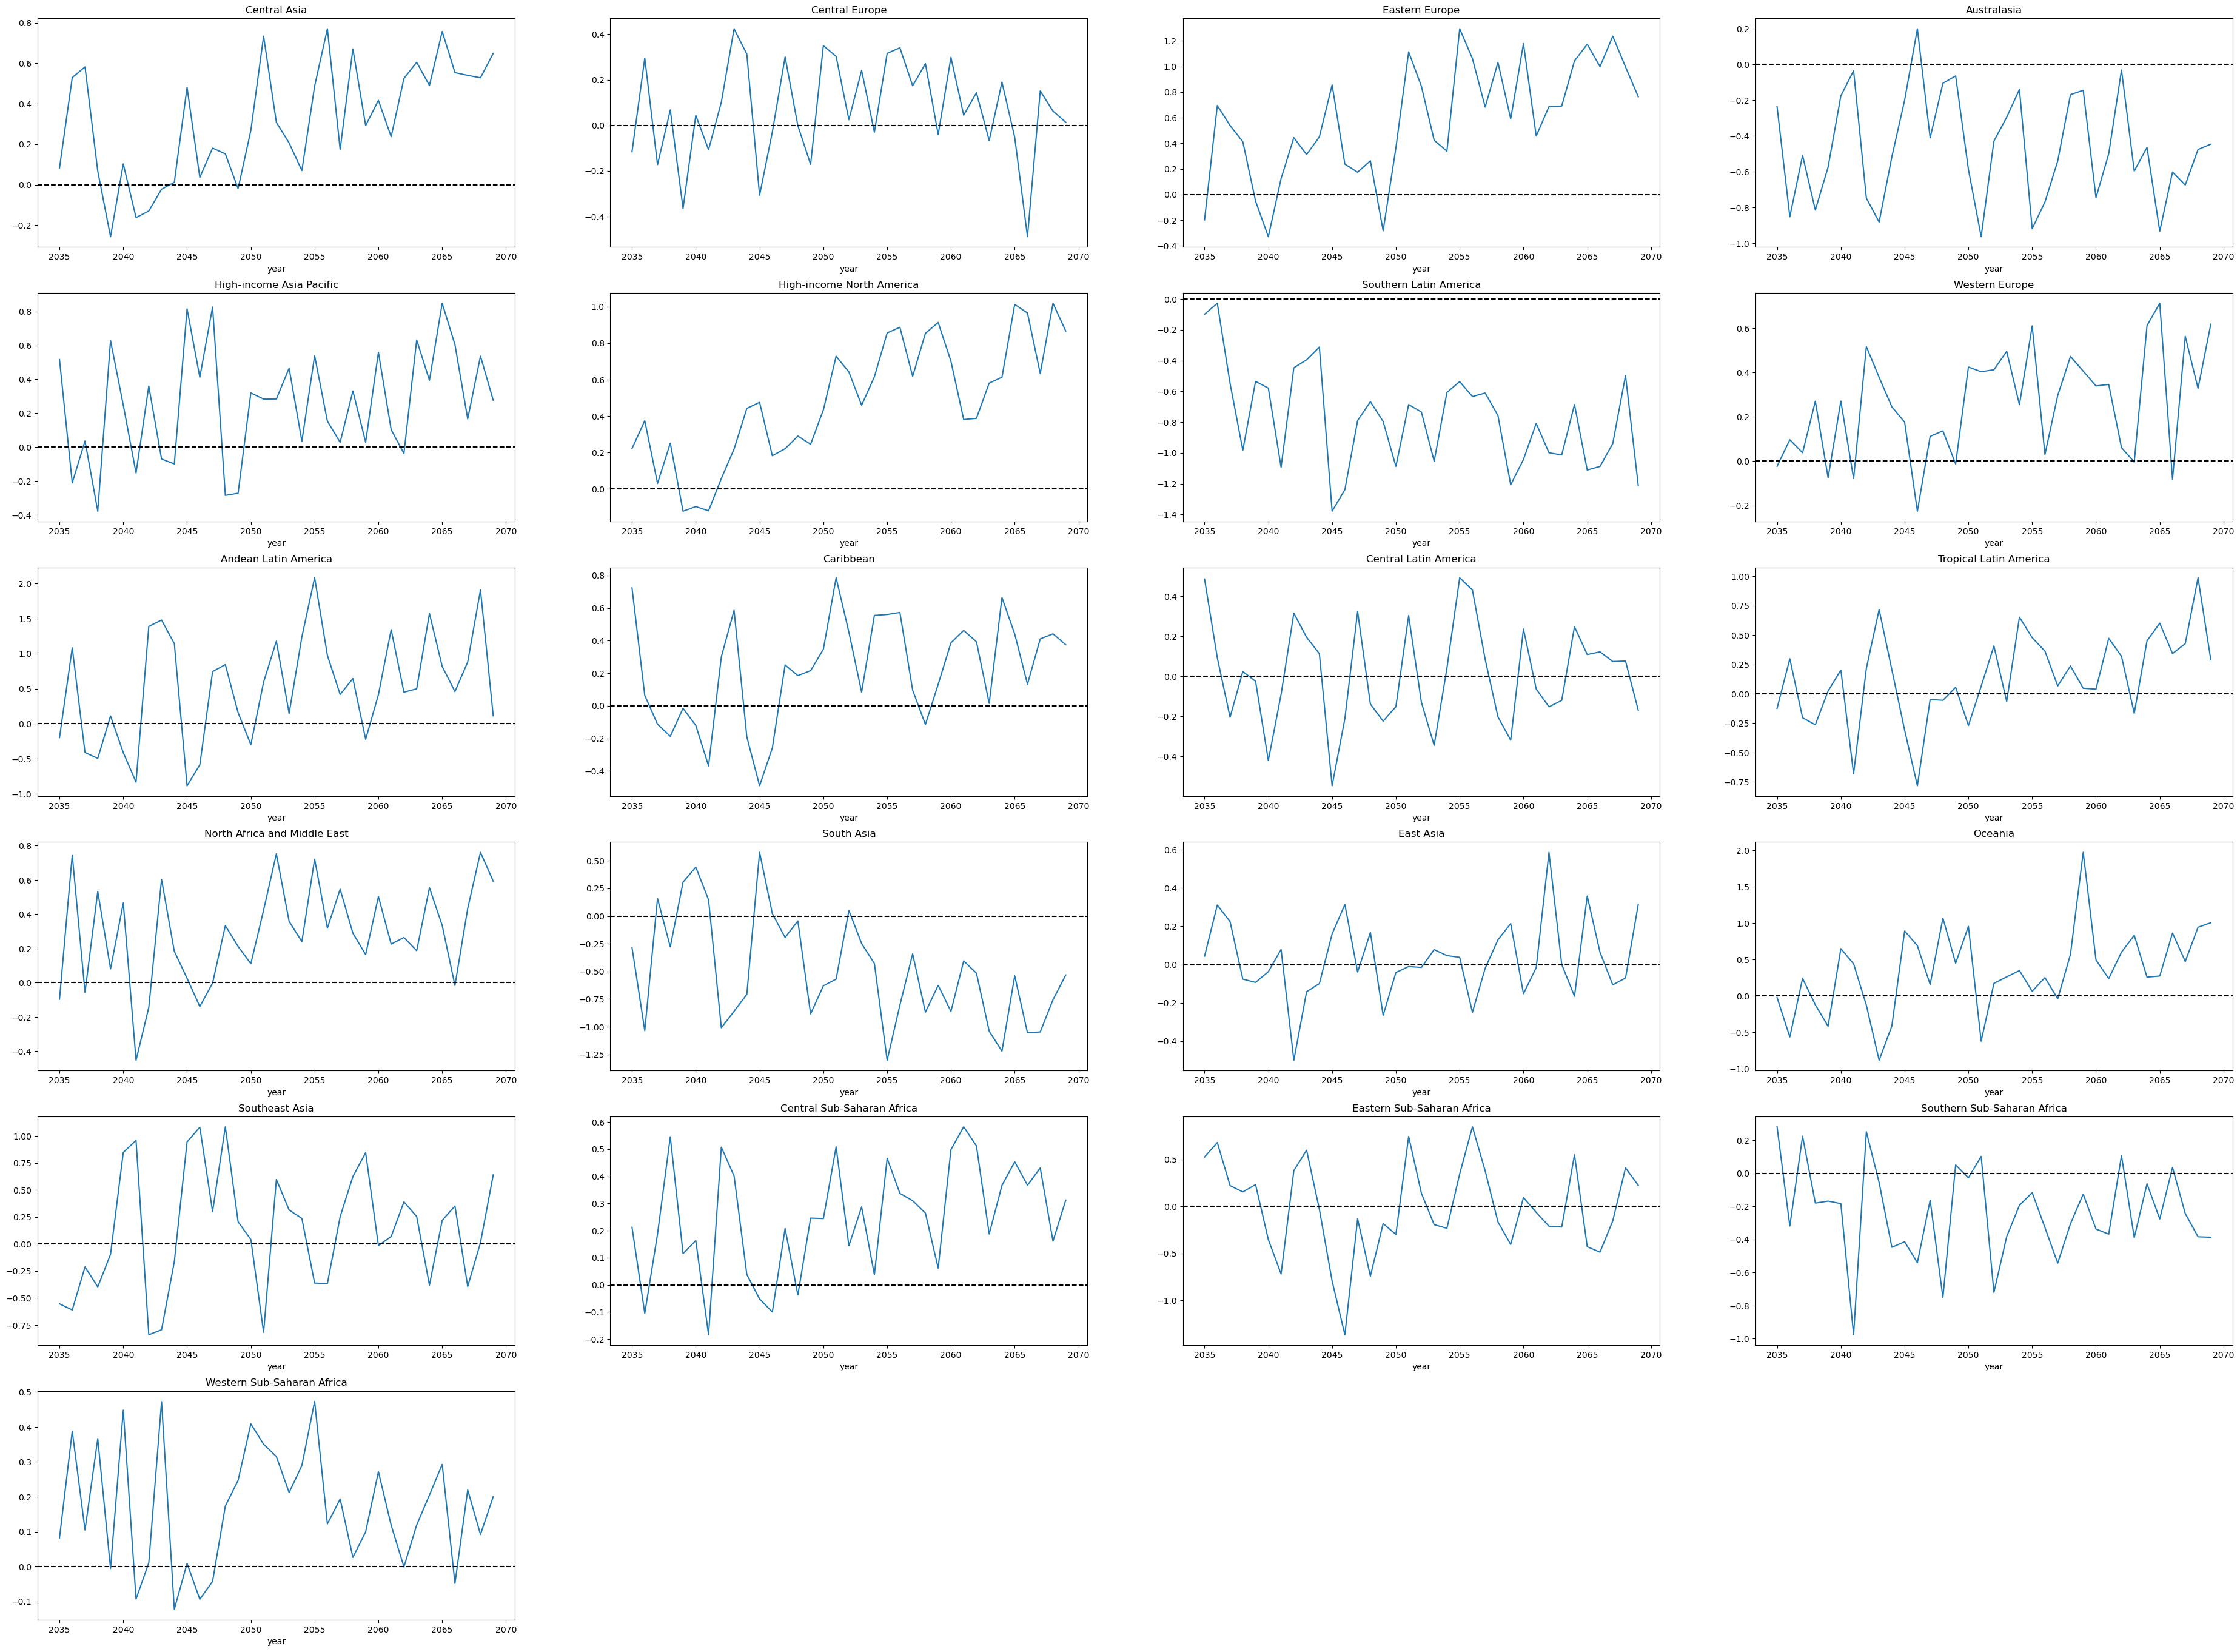

In [8]:
plt.figure(figsize=autosize_figure(5, 4, scale_factor=2, yscale_factor=3))
for i in range(21):
    plt.subplot(21, 4, i+1)
    (arise - ssp245).mean("ensemble").isel(region=i).plot()
    plt.axhline(0, color='k', linestyle='--')
    plt.title(ssp245["region"][i].values)